## **Experiment_01: Raw Image Retrieval Baseline**

**Retrieval using Image-Level Similarity**

Following the baseline notebook, we first evaluate pixel-level similarity methods: Mean Squared Error (MSE) and Structural Similarity Index Measure (SSIM).

| Method | Description |
|---|---|
| [MSE Similarity Measure](#mse)  | Pixel-level distance between the query image and each retrieval candidate. Lower MSE indicates higher similarity. |
| [SSIM Similarity Measure](#ssim)| Structural image-level similarity between the query image and each retrieval candidate. Higher SSIM indicates higher similarity. |

#### **Imports and paths**

In [14]:
from pathlib import Path
import sys
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from skimage.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
from torchvision import models

In [15]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [16]:
PROJECT_ROOT = Path.cwd().parents[2]
DATA_DIR = PROJECT_ROOT / "data"
PARTITION_CSV = DATA_DIR / "partition.csv"
IMAGES_DIR = PROJECT_ROOT / "8-Ball Pool.v3i.yolov11" / "train" / "images"
RETRIEVAL_DIR = PROJECT_ROOT / "detection_and_retrieval" / "retrieval"
if str(RETRIEVAL_DIR) not in sys.path:
    sys.path.append(str(RETRIEVAL_DIR))
RESULTS_DIR = RETRIEVAL_DIR / "outputs" / "experiment_01"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert PARTITION_CSV.exists(), f"Missing partition CSV: {PARTITION_CSV}"
assert IMAGES_DIR.exists(), f"Missing images directory: {IMAGES_DIR}"

In [17]:
len(os.listdir(IMAGES_DIR))

247

In [18]:
from utils.data import get_resnet_transform, load_retrieval_datasets, show_image


#### **Load Dataset**

In [19]:
transform = get_resnet_transform()

retrieval_pool, query_data = load_retrieval_datasets(
    images_dir=IMAGES_DIR,
    partition_csv=PARTITION_CSV,
    transform=transform
)

print(f"Retrieval pool size: {len(retrieval_pool)}")
print(f"Query set size: {len(query_data)}")

sample_img, sample_name = query_data[0]

print(f"Sample query filename: {sample_name}")
print(f"Sample query tensor shape: {sample_img.shape}")
print(f"Sample query tensor dtype: {sample_img.dtype}")

Retrieval pool size: 207
Query set size: 20
Sample query filename: 107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg
Sample query tensor shape: torch.Size([3, 224, 224])
Sample query tensor dtype: torch.float32


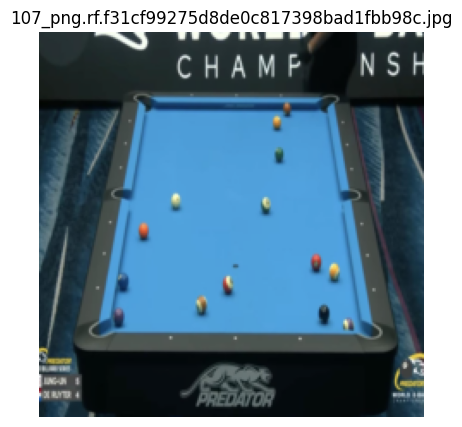

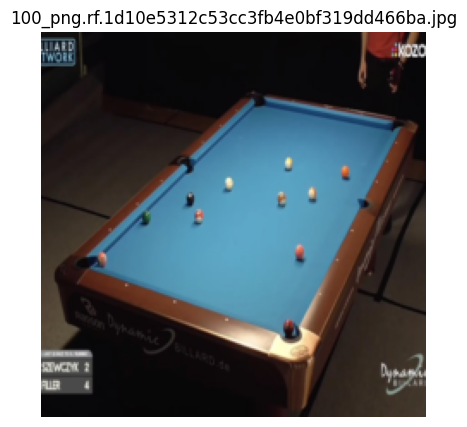

In [20]:
show_image(query_data, 0)
show_image(retrieval_pool, 1)

<a id="mse"></a>
#### **MSE Retrieval**

In [21]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])

def denormalize_image(img_tensor):
    """
    Converts a normalized tensor [3, H, W] into an image array [H, W, 3].
    """
    img = img_tensor.detach().cpu().permute(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = torch.clamp(img, 0, 1)
    return img.numpy()

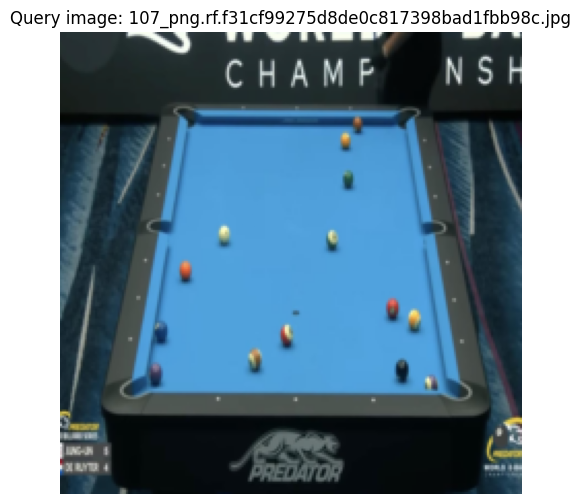

In [22]:
query_image, query_name = query_data[0]
query_image_show = denormalize_image(query_image)

plt.figure(figsize=(6, 6))
plt.imshow(query_image_show)
plt.title(f"Query image: {query_name}")
plt.axis("off")
plt.show()

In [23]:
from skimage.metrics import mean_squared_error

similarities_mse = np.zeros((len(retrieval_pool),))

query_np = query_image.detach().cpu().numpy()

for i in tqdm(range(len(retrieval_pool))):
    candidate_image, candidate_name = retrieval_pool[i]
    candidate_np = candidate_image.detach().cpu().numpy()

    similarities_mse[i] = mean_squared_error(query_np, candidate_np)

top5_mse_idx = np.argsort(similarities_mse)[:5]

print("Top-5 MSE results:")
for rank, idx in enumerate(top5_mse_idx, start=1):
    _, name = retrieval_pool[idx]
    print(f"{rank}. {name} | MSE distance = {similarities_mse[idx]:.4f}")

100%|██████████| 207/207 [00:02<00:00, 86.27it/s]


Top-5 MSE results:
1. 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg | MSE distance = 0.0661
2. 110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg | MSE distance = 0.1033
3. 25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg | MSE distance = 0.1203
4. 109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg | MSE distance = 0.1244
5. 24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg | MSE distance = 0.1548


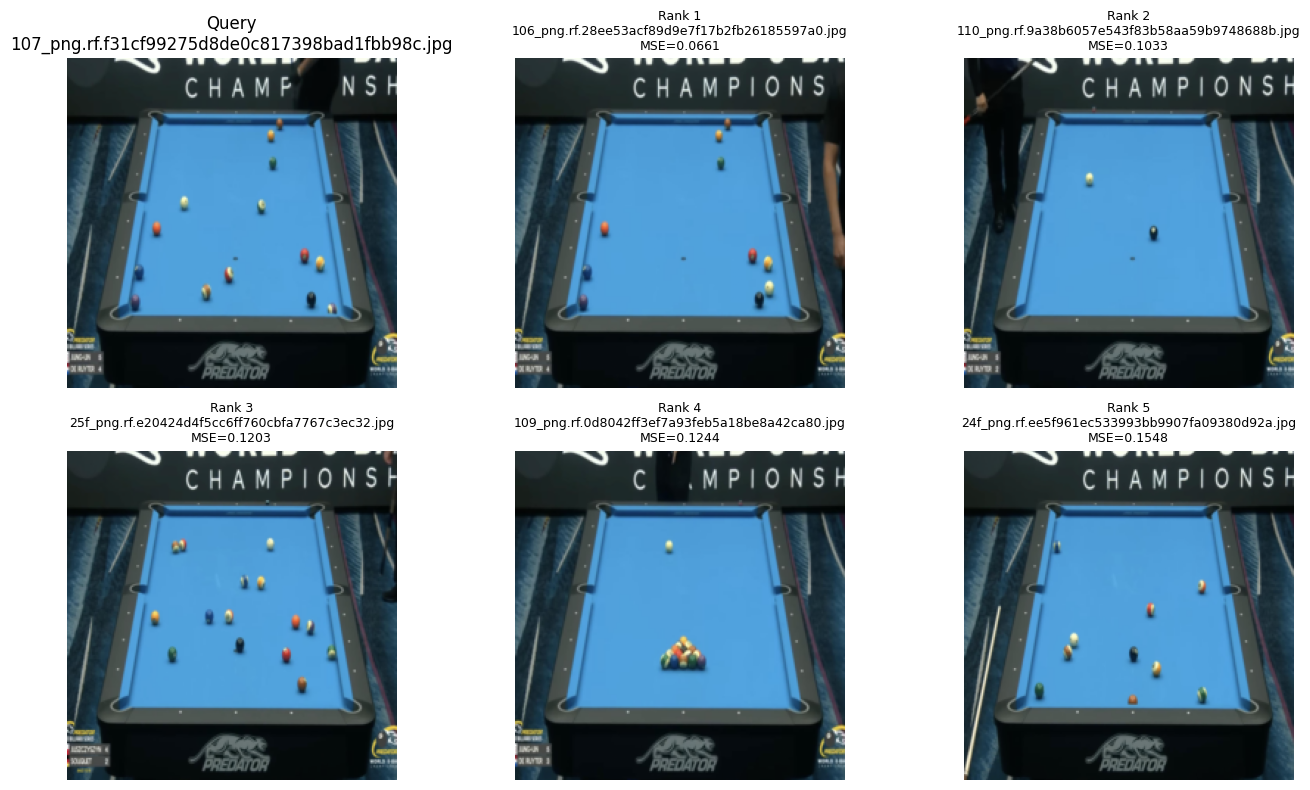

In [24]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title(f"Query\n{query_name}")
axarr[0][0].axis("off")

for j in range(1, 6):
    idx = top5_mse_idx[j - 1]
    img, name = retrieval_pool[idx]
    img_show = denormalize_image(img)

    axarr[j // 3][j % 3].imshow(img_show)
    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nMSE={similarities_mse[idx]:.4f}",
        fontsize=9
    )
    axarr[j // 3][j % 3].axis("off")

plt.tight_layout()
plt.show()

MSE between query and translated query: 0.3899
MSE between query and top-1 retrieved image: 0.0661


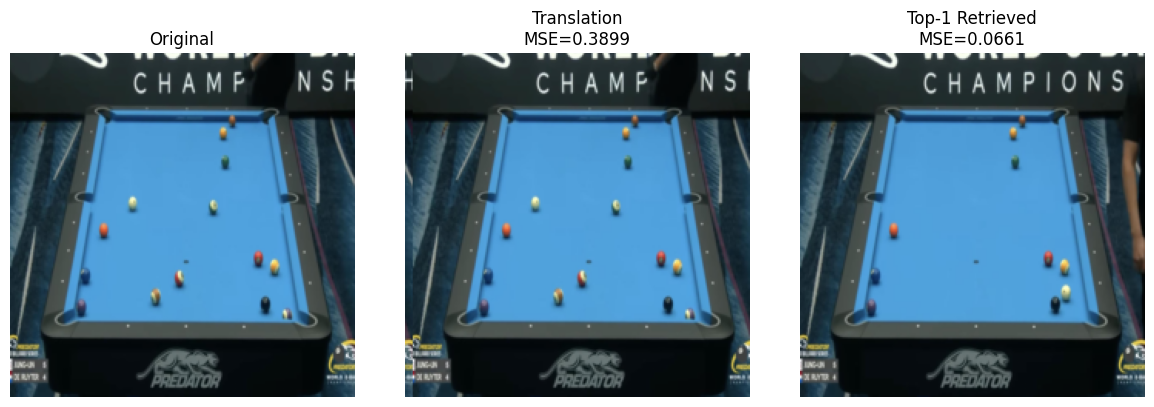

In [25]:
# Translate query image 5 pixels to the right
translate_query_image = torch.roll(query_image, shifts=5, dims=2)

sim_trans = mean_squared_error(
    query_image.detach().cpu().numpy(),
    translate_query_image.detach().cpu().numpy()
)

print(f"MSE between query and translated query: {sim_trans:.4f}")
print(f"MSE between query and top-1 retrieved image: {similarities_mse[top5_mse_idx[0]]:.4f}")

f, axarr = plt.subplots(1, 3, figsize=(12, 4))

axarr[0].imshow(query_image_show)
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(denormalize_image(translate_query_image))
axarr[1].set_title(f"Translation\nMSE={sim_trans:.4f}")
axarr[1].axis("off")

top1_img, top1_name = retrieval_pool[top5_mse_idx[0]]
axarr[2].imshow(denormalize_image(top1_img))
axarr[2].set_title(f"Top-1 Retrieved\nMSE={similarities_mse[top5_mse_idx[0]]:.4f}")
axarr[2].axis("off")

plt.tight_layout()
plt.show()

<a id="ssim"></a>
#### **SSIM Retrieval**

In [26]:
similarities_ssim = np.zeros((len(retrieval_pool),))

query_np = query_image.detach().cpu().numpy()

# SSIM expects channel-last format: [H, W, C]
query_np_hwc = np.transpose(query_np, (1, 2, 0))

for i in tqdm(range(len(retrieval_pool))):
    candidate_image, candidate_name = retrieval_pool[i]
    candidate_np = candidate_image.detach().cpu().numpy()
    candidate_np_hwc = np.transpose(candidate_np, (1, 2, 0))

    similarities_ssim[i] = ssim(
        query_np_hwc,
        candidate_np_hwc,
        channel_axis=2,
        data_range=candidate_np_hwc.max() - candidate_np_hwc.min()
    )

top5_ssim_idx = np.argsort(similarities_ssim)[::-1][:5]

print("Top-5 SSIM results:")
for rank, idx in enumerate(top5_ssim_idx, start=1):
    _, name = retrieval_pool[idx]
    print(f"{rank}. {name} | SSIM = {similarities_ssim[idx]:.4f}")

100%|██████████| 207/207 [00:02<00:00, 71.01it/s]

Top-5 SSIM results:
1. 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg | SSIM = 0.9301
2. 109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg | SSIM = 0.8946
3. 110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg | SSIM = 0.8735
4. 25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg | SSIM = 0.8422
5. 24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg | SSIM = 0.8355


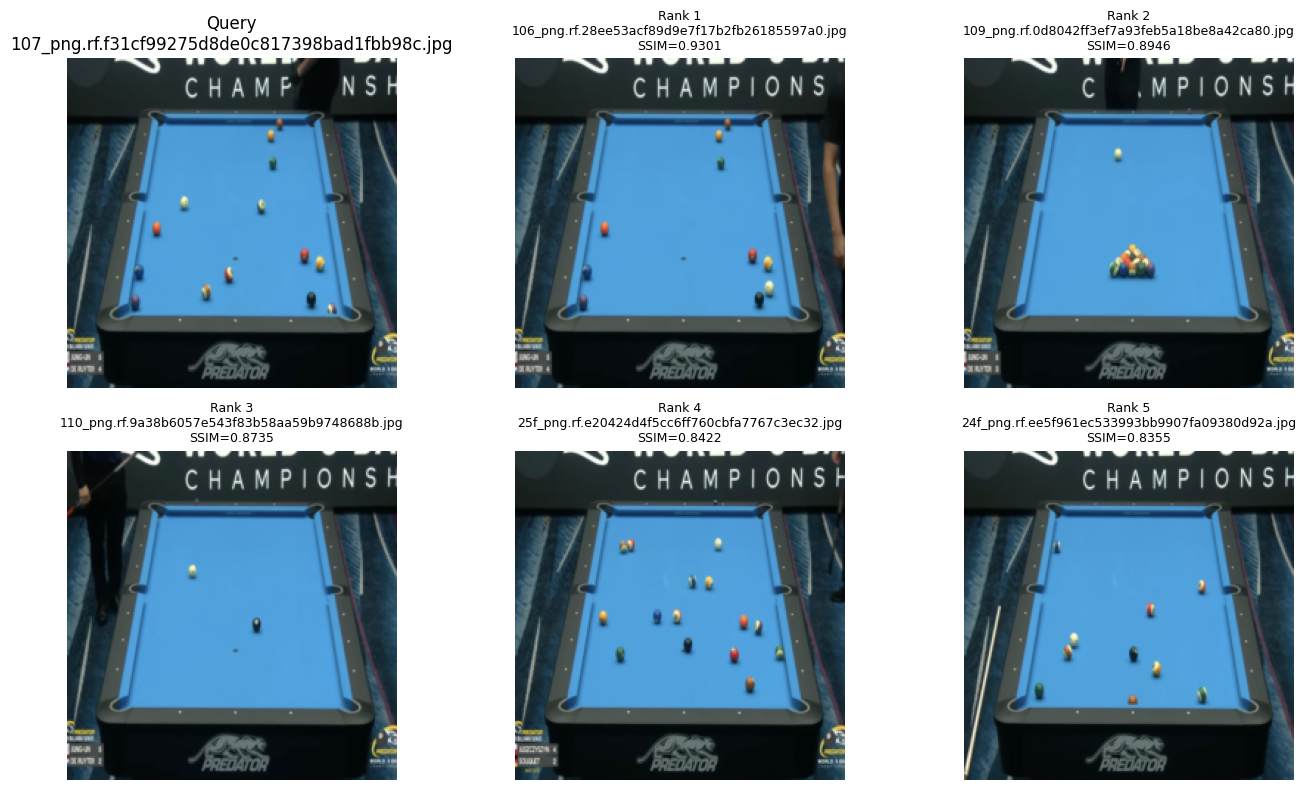

In [27]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title(f"Query\n{query_name}")
axarr[0][0].axis("off")

for j in range(1, 6):
    idx = top5_ssim_idx[j - 1]
    img, name = retrieval_pool[idx]
    img_show = denormalize_image(img)

    axarr[j // 3][j % 3].imshow(img_show)
    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nSSIM={similarities_ssim[idx]:.4f}",
        fontsize=9
    )
    axarr[j // 3][j % 3].axis("off")

plt.tight_layout()
plt.show()